Problem 1

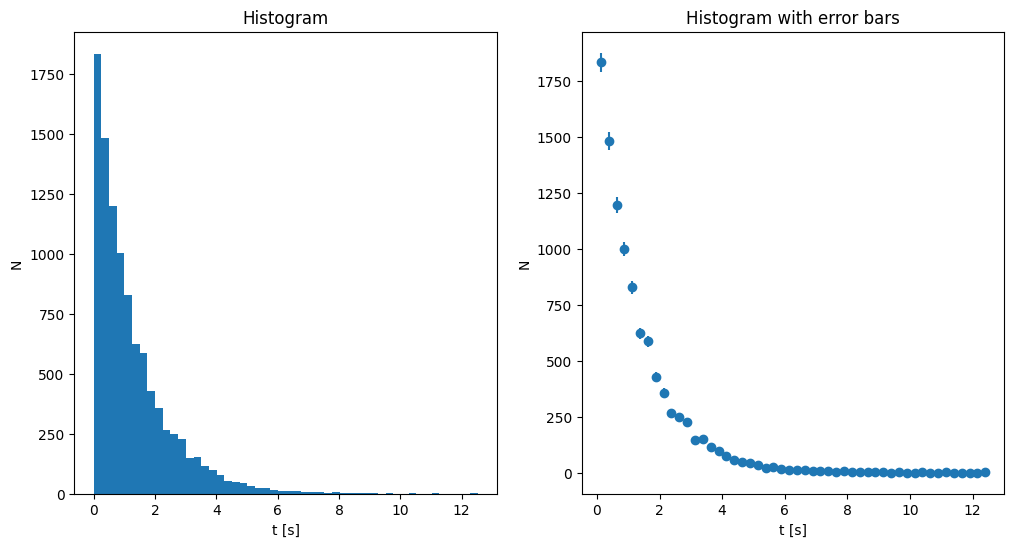

<Figure size 640x480 with 0 Axes>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.integrate as integrate
import random
from scipy.optimize import brentq
from scipy.optimize import curve_fit
from scipy.special import erfcinv

# Problem 1
with open('decay.txt', 'r') as f:
    lines = (line.strip() for line in f if line)
    t = [float(line) for line in lines]

figure, axis = plt.subplots(ncols=2,figsize=(12,6))

axis[0].hist(t, bins = 50)
axis[0].set(xlabel='t [s]', ylabel='N')
axis[0].set_title("Histogram")

counts_obs,bin_edges_obs = np.histogram(t, 50)
bin_centres_obs = (bin_edges_obs[:-1] + bin_edges_obs[1:])/2.
err = np.sqrt(counts_obs)

axis[1].set_title("Histogram with error bars")
axis[1].errorbar(bin_centres_obs, counts_obs, yerr=err, fmt='o')
axis[1].set(xlabel='t [s]', ylabel='N')
plt.savefig("E2_Problem_1.pdf")
plt.show()
plt.clf()

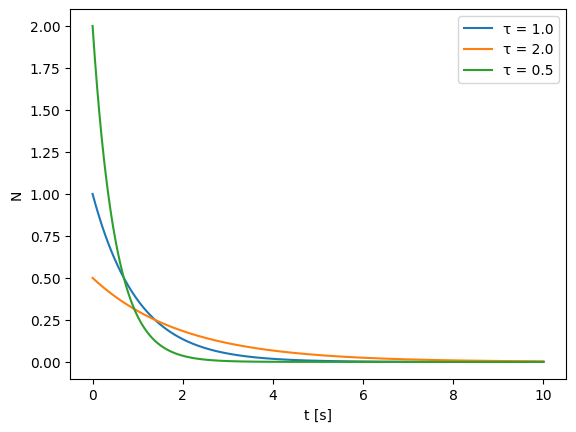

<Figure size 640x480 with 0 Axes>

In [3]:
# Problem 2
def decay_pdf(t,tau):
    return (1./tau)*np.exp(-1.0*t/tau)

x = np.linspace(0., 10., 1000)
f1 = decay_pdf(x, 1.0)
f2 = decay_pdf(x, 2.0)
f3 = decay_pdf(x, 0.5)

plt.plot(x, f1, label="τ = 1.0")
plt.plot(x, f2, label="τ = 2.0")
plt.plot(x, f3, label="τ = 0.5")
plt.xlabel('t [s]')
plt.ylabel('N')
plt.legend(loc="upper right")
plt.savefig("E2_Problem_2.pdf")
plt.show()
plt.clf()

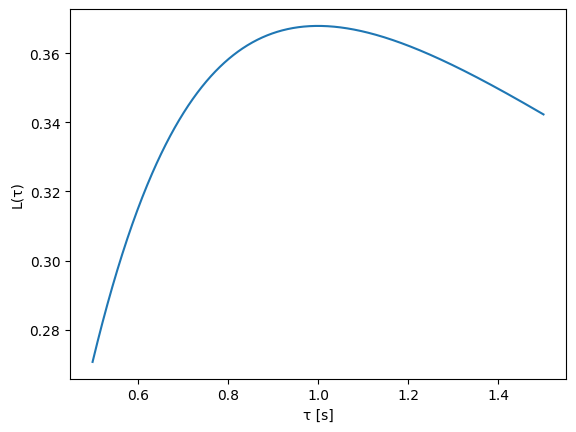

<Figure size 640x480 with 0 Axes>

In [4]:
# Problem 3
def Likelihood(tau, N, sum_t):
    return pow((1/tau),N)*np.exp(-sum_t/tau)

x = np.linspace(0.5, 1.5, 1000)
l = Likelihood(x, 1, 1.0)
plt.plot(x, l)
plt.xlabel('τ [s]')
plt.ylabel('L(τ)')
plt.savefig("E2_Problem_3.pdf")
plt.show()
plt.clf()

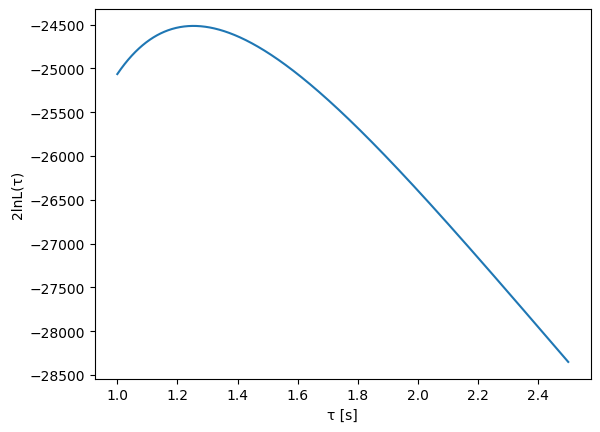

Maximum likeliheood estimator for mean lifetime is 1.254
Sigma_up uncertainty = 0.012
Sigma_dn uncertainty = 0.013


<Figure size 640x480 with 0 Axes>

In [8]:
# Problem 4
def lnL(tau, N, sum_t):
    return -2.0*N*np.log(tau) - 2.0*sum_t/tau

x = np.linspace(1.0, 2.5, 1000)
logLikelihood = lnL(x, len(t), sum(t))
plt.plot(x, logLikelihood)
plt.xlabel('τ [s]')
plt.ylabel('2lnL(τ)')
plt.savefig("E2_Problem_4.pdf")
plt.show()
plt.clf()

index = np.argmax(np.array(logLikelihood))
tau_hat = x[index]
print("Maximum likeliheood estimator for mean lifetime is " + str(round(tau_hat,3)))

def moved_lnL(tau):
    return lnL(tau, len(t), sum(t)) - logLikelihood[index] + 1.0

sigma_down = tau_hat - brentq(moved_lnL, 1.0, x[index])
sigma_up = brentq(moved_lnL, x[index], 1.5) - tau_hat

print("Sigma_up uncertainty = " + str(round(sigma_up,3)))
print("Sigma_dn uncertainty = " + str(round(sigma_down,3)))